In [1]:
import re
from pathlib import Path
import pandas as pd

log_path = Path(r"smoothing-48500580.out")
text = log_path.read_text(encoding="utf-8")

pattern = re.compile(
    r"\[(\d+)/500\]\s+idx=(\d+)\s+true=(.+?)\s{2}orig=(.+?)\s{2}"
    r"manifold=(.+?)\((\d+)/100\)\s{2}gauss=(.+?)\((\d+)/100\)\s{2}"
    r"m_stable=(True|False)\s{2}g_stable=(True|False)"
)

rows = []
for m in pattern.finditer(text):
    rows.append({
        "num": int(m.group(1)),
        "idx": int(m.group(2)),
        "true_class": m.group(3).strip(),
        "orig_pred": m.group(4).strip(),
        "manifold_pred": m.group(5).strip(),
        "manifold_votes": int(m.group(6)),
        "gauss_pred": m.group(7).strip(),
        "gauss_votes": int(m.group(8)),
        "m_stable": m.group(9) == "True",
        "g_stable": m.group(10) == "True",
    })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} / 500 results")
df.head()

Parsed 500 / 500 results


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes,gauss_pred,gauss_votes,m_stable,g_stable
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68,"unicycle, monocycle",35,False,True
1,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52,wire-haired fox terrier,13,True,False
2,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66,sturgeon,19,False,False
3,4,12447,"Eskimo dog, husky","dingo, warrigal, warragal, Canis dingo","timber wolf, grey wolf, gray wolf, Canis lupus",36,"timber wolf, grey wolf, gray wolf, Canis lupus",11,False,False
4,5,39489,shoji,shoji,chest,25,shoji,16,False,True


In [2]:
# === Summary Statistics ===
n = len(df)
m_stable = df["m_stable"].sum()
g_stable = df["g_stable"].sum()

# Orig accuracy (orig_pred == true_class)
df["orig_correct"] = df["orig_pred"] == df["true_class"]
df["manifold_correct"] = df["manifold_pred"] == df["true_class"]
df["gauss_correct"] = df["gauss_pred"] == df["true_class"]

# Manifold preserves original prediction
df["manifold_preserves_orig"] = df["manifold_pred"] == df["orig_pred"]
df["gauss_preserves_orig"] = df["gauss_pred"] == df["orig_pred"]

summary = pd.DataFrame({
    "Metric": [
        "Total images",
        "Certified stable",
        "Certified stable (%)",
        "Mean top-class votes",
        "Median top-class votes",
        "Preserves orig pred",
        "Preserves orig pred (%)",
        "Correct (matches true label)",
    ],
    "Manifold Smoothing": [
        n,
        int(m_stable),
        f"{m_stable/n*100:.1f}%",
        f"{df['manifold_votes'].mean():.1f}",
        f"{df['manifold_votes'].median():.0f}",
        int(df['manifold_preserves_orig'].sum()),
        f"{df['manifold_preserves_orig'].mean()*100:.1f}%",
        f"{df['manifold_correct'].sum()} ({df['manifold_correct'].mean()*100:.1f}%)",
    ],
    "Gaussian (Isotropic)": [
        n,
        int(g_stable),
        f"{g_stable/n*100:.1f}%",
        f"{df['gauss_votes'].mean():.1f}",
        f"{df['gauss_votes'].median():.0f}",
        int(df['gauss_preserves_orig'].sum()),
        f"{df['gauss_preserves_orig'].mean()*100:.1f}%",
        f"{df['gauss_correct'].sum()} ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
})

print("Original model accuracy on these 500 images:", f"{df['orig_correct'].mean()*100:.1f}%")
print()
summary.style.hide(axis='index')

Original model accuracy on these 500 images: 68.8%



Metric,Manifold Smoothing,Gaussian (Isotropic)
Total images,500,500
Certified stable,396,407
Certified stable (%),79.2%,81.4%
Mean top-class votes,72.1,27.4
Median top-class votes,75,23
Preserves orig pred,396,407
Preserves orig pred (%),79.2%,81.4%
Correct (matches true label),324 (64.8%),327 (65.4%)


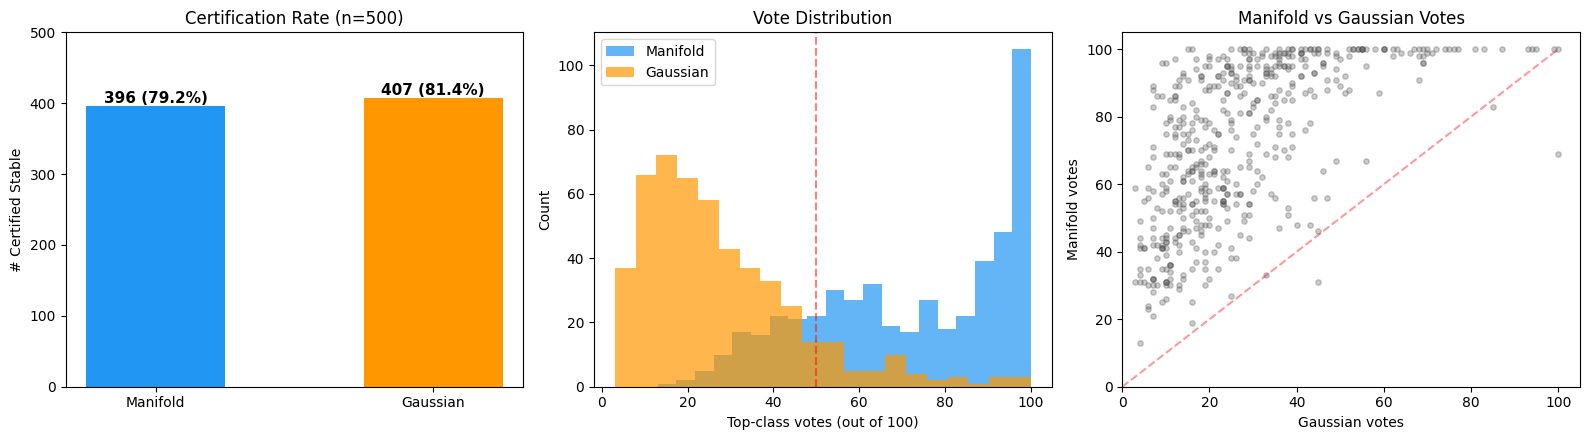

Saved: smoothing_results_summary.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1) Bar chart: certified stable
ax = axes[0]
bars = ax.bar(["Manifold", "Gaussian"], [m_stable, g_stable], 
              color=["#2196F3", "#FF9800"], width=0.5)
ax.set_ylabel("# Certified Stable")
ax.set_title(f"Certification Rate (n={n})")
ax.set_ylim(0, n)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, 
            f"{b.get_height():.0f} ({b.get_height()/n*100:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")

# 2) Vote distribution histogram
ax = axes[1]
ax.hist(df["manifold_votes"], bins=20, alpha=0.7, label="Manifold", color="#2196F3")
ax.hist(df["gauss_votes"], bins=20, alpha=0.7, label="Gaussian", color="#FF9800")
ax.set_xlabel("Top-class votes (out of 100)")
ax.set_ylabel("Count")
ax.set_title("Vote Distribution")
ax.legend()
ax.axvline(50, color="red", ls="--", alpha=0.5, label="majority")

plt.tight_layout()
plt.savefig("smoothing_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: smoothing_results_summary.png")

In [12]:
# === Detailed Breakdown ===
print("=" * 60)
print("STABILITY CROSS-TABLE")
print("=" * 60)
ct = pd.crosstab(df["m_stable"], df["g_stable"], 
                 rownames=["Manifold Stable"], colnames=["Gaussian Stable"],
                 margins=True)
print(ct)
print()
print(f"Both stable:           {((df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Only manifold stable:  {((df['m_stable']) & (~df['g_stable'])).sum()}")
print(f"Only gaussian stable:  {((~df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Neither stable:        {((~df['m_stable']) & (~df['g_stable'])).sum()}")

STABILITY CROSS-TABLE
Gaussian Stable  False  True  All
Manifold Stable                  
False               42    62  104
True                51   345  396
All                 93   407  500

Both stable:           345
Only manifold stable:  51
Only gaussian stable:  62
Neither stable:        42


In [13]:
# === Simple Results Comparison ===

results_table = pd.DataFrame({
    "": ["Original (no noise)", "Manifold Smoothed", "Gaussian Smoothed"],
    "Matches True Label": [
        f"{df['orig_correct'].sum()}/500 ({df['orig_correct'].mean()*100:.1f}%)",
        f"{df['manifold_correct'].sum()}/500 ({df['manifold_correct'].mean()*100:.1f}%)",
        f"{df['gauss_correct'].sum()}/500 ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
    "Certified Stable": [
        "—",
        f"{df['m_stable'].sum()}/500 ({df['m_stable'].mean()*100:.1f}%)",
        f"{df['g_stable'].sum()}/500 ({df['g_stable'].mean()*100:.1f}%)",
    ],
    "Mean Votes": [
        "—",
        f"{df['manifold_votes'].mean():.1f}/100",
        f"{df['gauss_votes'].mean():.1f}/100",
    ],
}).set_index("")

display(results_table)

# Head-to-head: true label
both = (df["manifold_correct"] & df["gauss_correct"]).sum()
only_m = (df["manifold_correct"] & ~df["gauss_correct"]).sum()
only_g = (~df["manifold_correct"] & df["gauss_correct"]).sum()
none_ = (~df["manifold_correct"] & ~df["gauss_correct"]).sum()

h2h = pd.DataFrame({
    "": ["Both correct", "Only Manifold correct", "Only Gaussian correct", "Neither correct"],
    "Count": [both, only_m, only_g, none_],
}).set_index("")

print("\nHead-to-head (which method matches TRUE label):")
display(h2h)

,Matches True Label,Certified Stable,Mean Votes
,,,
Original (no noise),344/500 (68.8%),—,—
Manifold Smoothed,324/500 (64.8%),396/500 (79.2%),72.1/100
Gaussian Smoothed,327/500 (65.4%),407/500 (81.4%),27.4/100



Head-to-head (which method matches TRUE label):


,Count
,
Both correct,284
Only Manifold correct,40
Only Gaussian correct,43
Neither correct,133


In [15]:
# === Cases where method is UNSTABLE but corrects to true label ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    corrects = df[~df[stable_col] & df[correct_col] & ~df["orig_correct"]]
    print(f"{method} UNSTABLE but corrects to true label: {len(corrects)}")
    if len(corrects) > 0:
        display(corrects[["num","idx","true_class","orig_pred",pred_col,votes_col]].reset_index(drop=True))
    print()

# === Cases where method is STABLE but wrong (orig was already wrong) ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    stable_wrong = df[df[stable_col] & ~df["orig_correct"]]
    print(f"{method} STABLE but wrong (orig was wrong too): {len(stable_wrong)}")
    if len(stable_wrong) > 0:
        display(stable_wrong[["num","idx","true_class","orig_pred",pred_col,votes_col]].head(15).reset_index(drop=True))
    print()

Manifold UNSTABLE but corrects to true label: 21


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68
1,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66
2,30,33109,modem,"hard disc, hard disk, fixed disk",modem,44
3,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",54
4,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",21
5,66,20304,altar,throne,altar,65
6,74,26803,"dock, dockage, docking facility","paddlewheel, paddle wheel","dock, dockage, docking facility",43
7,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",48
8,117,9801,miniature schnauzer,Kerry blue terrier,miniature schnauzer,63
9,122,7134,dowitcher,"red-backed sandpiper, dunlin, Erolia alpina",dowitcher,49



Gaussian UNSTABLE but corrects to true label: 15


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,wire-haired fox terrier,13
1,29,37237,"projectile, missile",missile,"projectile, missile",24
2,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",16
3,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",7
4,104,36537,"plow, plough",oxcart,"plow, plough",11
5,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",20
6,121,31919,maillot,"maillot, tank suit",maillot,22
7,223,48525,alp,"valley, vale",alp,29
8,280,147,"great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...",19
9,283,43850,turnstile,"tricycle, trike, velocipede",turnstile,10



Manifold STABLE but wrong (orig was wrong too): 93


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,61
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,70
3,23,821,bulbul,bee eater,bee eater,76
4,29,37237,"projectile, missile",missile,missile,64
5,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",59
6,34,3918,tick,rhinoceros beetle,rhinoceros beetle,51
7,44,38340,rotisserie,safe,safe,91
8,51,24712,"chime, bell, gong",tile roof,tile roof,58
9,65,37213,"projectile, missile","aircraft carrier, carrier, flattop, attack air...","aircraft carrier, carrier, flattop, attack air...",82



Gaussian STABLE but wrong (orig was wrong too): 95


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","unicycle, monocycle",35
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,16
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,16
3,23,821,bulbul,bee eater,bee eater,42
4,24,15118,"ground beetle, carabid beetle",tiger beetle,tiger beetle,23
5,30,33109,modem,"hard disc, hard disk, fixed disk","hard disc, hard disk, fixed disk",4
6,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",10
7,40,11076,Irish water spaniel,standard poodle,standard poodle,22
8,47,14644,"tiger, Panthera tigris","lynx, catamount","lynx, catamount",31
9,51,24712,"chime, bell, gong",tile roof,tile roof,7


In [16]:
# === Vote statistics for stable vs unstable ===
print("Mean manifold votes when STABLE:  ", df.loc[df['m_stable'], 'manifold_votes'].mean().round(1))
print("Mean manifold votes when UNSTABLE:", df.loc[~df['m_stable'], 'manifold_votes'].mean().round(1))
print()
print("Mean gaussian votes when STABLE:  ", df.loc[df['g_stable'], 'gauss_votes'].mean().round(1))
print("Mean gaussian votes when UNSTABLE:", df.loc[~df['g_stable'], 'gauss_votes'].mean().round(1))

Mean manifold votes when STABLE:   78.7
Mean manifold votes when UNSTABLE: 46.6

Mean gaussian votes when STABLE:   30.9
Mean gaussian votes when UNSTABLE: 12.3


In [17]:
# === Save parsed results as CSV ===
df.to_csv("smoothing_results_500.csv", index=False)
print("Saved: smoothing_results_500.csv")
print(f"\nManifold: {m_stable}/{n} ({m_stable/n*100:.1f}%) certified stable")
print(f"Gaussian: {g_stable}/{n} ({g_stable/n*100:.1f}%) certified stable")

Saved: smoothing_results_500.csv

Manifold: 396/500 (79.2%) certified stable
Gaussian: 407/500 (81.4%) certified stable


## Full Results from JSON (with certification, volumes, concept scores)
Load the detailed JSONL results produced by `run_smoothing.py` which include Cohen et al. certification, concept-level certification, stability scores, and certified volumes.

In [ ]:
import json
import numpy as np
from pathlib import Path

# --- Load JSONL results ---
# Adjust sigma folder as needed
SIGMA = 0.25
DATA_DIR = Path("..") / "smoothing_data" / f"sigma_{SIGMA:.2f}"

jsonl_path = DATA_DIR / "smoothing_results_imagenet.jsonl"
json_path = DATA_DIR / "smoothing_results_imagenet.json"

results = []
if jsonl_path.exists():
    with open(jsonl_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    results.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    print(f"Loaded {len(results)} results from JSONL")
elif json_path.exists():
    with open(json_path, 'r') as f:
        results = json.load(f)
    print(f"Loaded {len(results)} results from JSON")
else:
    print(f"ERROR: No results found at {jsonl_path} or {json_path}")

# Helper for safe means over finite values
def _finite(vals):
    return [v for v in vals if np.isfinite(v) and abs(v) < 1e30]

def _safe_mean(vals):
    fv = _finite(vals)
    return np.mean(fv) if fv else float('nan')

def _safe_median(vals):
    fv = _finite(vals)
    return np.median(fv) if fv else float('nan')

In [ ]:
# ============================================================
# TABLE 1: DOWNSTREAM ACCURACY
# ============================================================
n_res = len(results)

orig_correct = sum(1 for r in results if r['pred_orig'] == r['label_true'])
m_correct = sum(1 for r in results if r['pred_manifold'] == r['label_true'])
g_correct = sum(1 for r in results if r['pred_gaussian'] == r['label_true'])
m_preserves = sum(1 for r in results if r['pred_manifold'] == r['pred_orig'])
g_preserves = sum(1 for r in results if r['pred_gaussian'] == r['pred_orig'])

table1 = pd.DataFrame({
    "Method": [f"Original", f"Manifold (σ={SIGMA})", f"Gaussian (σ={SIGMA})"],
    "Accuracy (↑)": [
        f"{orig_correct}/{n_res} ({orig_correct/n_res*100:.1f}%)",
        f"{m_correct}/{n_res} ({m_correct/n_res*100:.1f}%)",
        f"{g_correct}/{n_res} ({g_correct/n_res*100:.1f}%)",
    ],
    "Preserves Orig Pred": [
        "—",
        f"{m_preserves}/{n_res} ({m_preserves/n_res*100:.1f}%)",
        f"{g_preserves}/{n_res} ({g_preserves/n_res*100:.1f}%)",
    ],
}).set_index("Method")

print("TABLE 1: DOWNSTREAM ACCURACY")
display(table1)

In [ ]:
# ============================================================
# TABLE 2: CERTIFIED DOWNSTREAM ACCURACY (Cohen et al.)
# ============================================================
def _class_stats(results, method):
    cert_key = f'class_cert_{method}'
    pred_key = f'pred_{method}'
    n = len(results)
    n_certified = 0
    n_correct_certified = 0
    n_stable_certified = 0
    n_abstained = 0
    radii = []
    for r in results:
        cc = r.get(cert_key, {})
        if cc.get('abstained', True):
            n_abstained += 1
        else:
            n_certified += 1
            rad = cc.get('certified_radius', 0)
            if np.isfinite(rad):
                radii.append(rad)
            if r[pred_key] == r['label_true']:
                n_correct_certified += 1
            if r[pred_key] == r['pred_orig']:
                n_stable_certified += 1
    return {
        'Certified Acc (↑)': f"{n_correct_certified}/{n} ({n_correct_certified/n*100:.1f}%)",
        'Certified Stability (↑)': f"{n_stable_certified}/{n} ({n_stable_certified/n*100:.1f}%)",
        'Abstain Rate (↓)': f"{n_abstained}/{n} ({n_abstained/n*100:.1f}%)",
        '#Certified': f"{n_certified}/{n}",
        'Mean Radius (↑)': f"{np.mean(radii):.4f}" if radii else "N/A",
        'Median Radius': f"{np.median(radii):.4f}" if radii else "N/A",
    }

m_cls = _class_stats(results, 'manifold')
g_cls = _class_stats(results, 'gaussian')

table2 = pd.DataFrame({f"Manifold (σ={SIGMA})": m_cls, f"Gaussian (σ={SIGMA})": g_cls})

print("TABLE 2: CERTIFIED DOWNSTREAM ACCURACY (Cohen et al.)")
display(table2)

In [ ]:
# ============================================================
# TABLE 3: CONCEPT-LEVEL CERTIFICATION (concept space radius)
# ============================================================
TOP_K = 20  # number of top concepts tracked

m_surv = [r.get('mean_concept_survival_manifold', 0) for r in results]
g_surv = [r.get('mean_concept_survival_gaussian', 0) for r in results]
m_cert = [r.get('n_concepts_certified_manifold', 0) for r in results]
g_cert = [r.get('n_concepts_certified_gaussian', 0) for r in results]
m_min_r = [r.get('min_concept_radius_manifold', 0) for r in results]
g_min_r = [r.get('min_concept_radius_gaussian', 0) for r in results]
m_mean_r = [r.get('mean_concept_radius_manifold', 0) for r in results]
g_mean_r = [r.get('mean_concept_radius_gaussian', 0) for r in results]
m_overlap = [r.get('overlap_manifold', 0) for r in results]
g_overlap = [r.get('overlap_gaussian', 0) for r in results]

table3 = pd.DataFrame({
    "Metric": [
        f"Mean Survival Rate (↑)",
        f"Mean #Certified/{TOP_K} (↑)",
        "Mean Top-K Overlap (↑)",
        "Mean Concept Radius (↑)",
        "Mean Min Concept Radius",
    ],
    f"Manifold (σ={SIGMA})": [
        f"{np.mean(m_surv):.3f}",
        f"{np.mean(m_cert):.1f}",
        f"{np.mean(m_overlap):.3f}",
        f"{_safe_mean(m_mean_r):.4f}",
        f"{_safe_mean(m_min_r):.4f}",
    ],
    f"Gaussian (σ={SIGMA})": [
        f"{np.mean(g_surv):.3f}",
        f"{np.mean(g_cert):.1f}",
        f"{np.mean(g_overlap):.3f}",
        f"{_safe_mean(g_mean_r):.4f}",
        f"{_safe_mean(g_min_r):.4f}",
    ],
}).set_index("Metric")

print(f"TABLE 3: CONCEPT CERTIFICATION (top-{TOP_K} concepts)")
display(table3)

In [ ]:
# ============================================================
# TABLE 4: CONCEPT STABILITY SCORES
# ============================================================
score_keys = ['concept_fidelity', 'rank_correlation', 'concept_drift',
              'spurious_act_rate', 'act_drop_score', 'act_gain_score']
score_labels = ['Fidelity (r) ↑', 'Rank Corr (τ) ↑', 'Drift (L2) ↓',
                'Spurious Act Rate ↓', 'Act Drop Score ↓', 'Act Gain Score ↓']

rows_m = []
rows_g = []
for k in score_keys:
    rows_m.append(np.mean([r.get('scores_manifold', {}).get(k, 0) for r in results]))
    rows_g.append(np.mean([r.get('scores_gaussian', {}).get(k, 0) for r in results]))

table4 = pd.DataFrame({
    "Metric": score_labels,
    f"Manifold (σ={SIGMA})": [f"{v:.4f}" for v in rows_m],
    f"Gaussian (σ={SIGMA})": [f"{v:.4f}" for v in rows_g],
}).set_index("Metric")

print("TABLE 4: CONCEPT STABILITY SCORES")
display(table4)

In [ ]:
# ============================================================
# TABLE 5: CERTIFIED VOLUME (4 quantities, log-space)
# ============================================================
vol_keys = ['log_vol_iso_D', 'log_vol_iso_k', 'log_vol_mani_pred', 'log_vol_mani_actual']
vol_labels = [
    'Qty1: Iso Ball (D)  — C_D · r_iso^D',
    'Qty2: Iso Ball (k)  — C_k · r_iso^k',
    'Qty3: Mani w/ iso-r — C_k · r_iso^k · √det(Λ)',
    'Qty4: Mani Ellipsoid — C_k · r_mani^k · √det(Λ)',
]

r_isos = [r.get('volumes', {}).get('r_iso', 0) for r in results]
r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]

vol_rows = []
for vk, vl in zip(vol_keys, vol_labels):
    vals = [r.get('volumes', {}).get(vk, -np.inf) for r in results]
    fv = _finite(vals)
    vol_rows.append({
        'Quantity': vl,
        'Mean (log)': f"{np.mean(fv):.2f}" if fv else "N/A",
        'Median (log)': f"{np.median(fv):.2f}" if fv else "N/A",
        'Std (log)': f"{np.std(fv):.2f}" if fv else "N/A",
        '#Finite': f"{len(fv)}/{n_res}",
    })

table5 = pd.DataFrame(vol_rows).set_index('Quantity')

mean_k = np.mean([r.get('n_eigenvalues', 0) for r in results])
D = results[0].get('volumes', {}).get('D', 8192) if results else 8192

print("TABLE 5: CERTIFIED VOLUME (log-space, finite samples only)")
print(f"  σ = {SIGMA}")
print(f"  r_iso  (Gaussian):  mean={_safe_mean(r_isos):.4f}, >0: {sum(1 for r in r_isos if r > 0)}/{n_res}")
print(f"  r_mani (Manifold):  mean={_safe_mean(r_manis):.4f}, >0: {sum(1 for r in r_manis if r > 0)}/{n_res}")
print(f"  Effective manifold dim: mean k={mean_k:.1f} / D={D}")
print()
display(table5)

print("\nNote: Qty1-3 are -Inf (excluded) when r_iso=0 (Gaussian abstained).")
print("      Qty4 is -Inf (excluded) when r_mani=0 (Manifold abstained).")